# Phân tích Khám phá và Chẩn đoán Dữ liệu (EDA)

Notebook này phân tích `AMZN.csv` và `gold_price.csv` cho dự báo chuỗi thời gian. Chúng tôi thực hiện tóm tắt thống kê, điền khuyết (imputation), phân rã (decomposition), kiểm định tính dừng (stationarity testing) và phân tích tự tương quan (autocorrelation) để cung cấp thông tin cho các mô hình chuỗi cửa sổ trượt (sliding window).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')


## Tải và Làm sạch Dữ liệu Cổ phiếu Amazon (AMZN)

Chúng tôi tải dữ liệu, thiết lập cột `Date` làm chỉ số thời gian theo trình tự, và xử lý mọi giá trị bị thiếu bằng phương pháp điền tới (forward-fill).


In [2]:
df_amzn = pd.read_csv('../data/AMZN.csv')
if 'Date' in df_amzn.columns:
    df_amzn['Date'] = pd.to_datetime(df_amzn['Date'])
    df_amzn.set_index('Date', inplace=True)
    df_amzn.sort_index(inplace=True)

print("Số lượng Giá trị Thiếu ban đầu của AMZN:", df_amzn['Close'].isnull().sum())
df_amzn['Close'] = df_amzn['Close'].ffill().bfill()

display(df_amzn[['Close']].describe())


Số lượng Giá trị Thiếu ban đầu của AMZN: 0


,Close
count,6684.000000
mean,34.020316
std,49.829566
min,0.069792
25%,2.042500
50%,7.104750
75%,45.135750
max,186.570496


## Tải và Làm sạch Dữ liệu Giá Vàng

Chúng tôi thực hiện các bước tiền xử lý tương tự cho `gold_price.csv`.


In [3]:
df_gold = pd.read_csv('../data/gold_price.csv')
date_col = 'Date' if 'Date' in df_gold.columns else df_gold.columns[0]
df_gold[date_col] = pd.to_datetime(df_gold[date_col])
df_gold.set_index(date_col, inplace=True)
df_gold.sort_index(inplace=True)

# Điều chỉnh cột mục tiêu dựa trên dữ liệu có sẵn, chuẩn hóa thành 'Close' nếu có thể
target_gold = 'Close' if 'Close' in df_gold.columns else ('Price' if 'Price' in df_gold.columns else df_gold.columns[0])

print("Số lượng Giá trị Thiếu ban đầu của Vàng:", df_gold[target_gold].isnull().sum())
df_gold[target_gold] = df_gold[target_gold].ffill().bfill()

display(df_gold[[target_gold]].describe())


Số lượng Giá trị Thiếu ban đầu của Vàng: 141


,price
count,13461.000000
mean,562.594552
std,477.447084
min,34.750000
25%,279.000000
50%,382.800000
75%,762.500000
max,2067.150000


## Trực quan hóa Chuỗi thời gian

Trực quan hóa các xu hướng thô để hiểu về biến động (volatility) và các sự thay đổi trạng thái (regime shifts) qua thời gian.


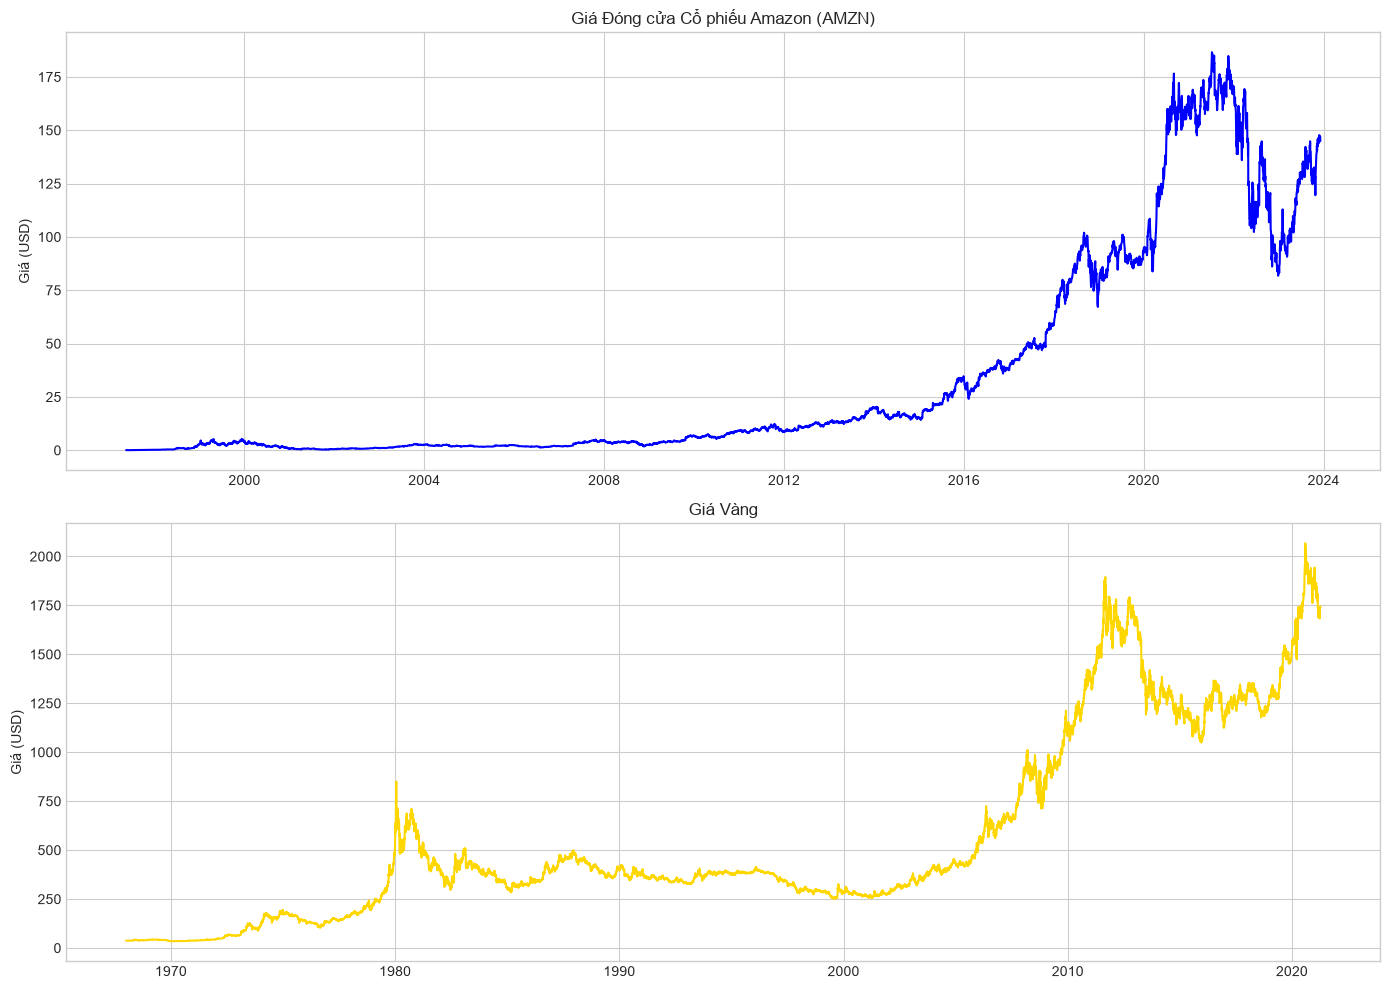

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(df_amzn.index, df_amzn['Close'], color='blue')
axes[0].set_title('Giá Đóng cửa Cổ phiếu Amazon (AMZN)')
axes[0].set_ylabel('Giá (USD)')

axes[1].plot(df_gold.index, df_gold[target_gold], color='gold')
axes[1].set_title('Giá Vàng')
axes[1].set_ylabel('Giá (USD)')

plt.tight_layout()
plt.show()


## Phân rã Chuỗi thời gian

Chúng tôi phân rã chuỗi thành các thành phần Xu hướng (Trend), Tính mùa vụ (Seasonality) và Phần dư (Residuals) để hiểu rõ hơn về các mẫu hình ẩn bên dưới. Chúng tôi sử dụng một chu kỳ bất kỳ (ví dụ: 252 ngày giao dịch xấp xỉ một năm).


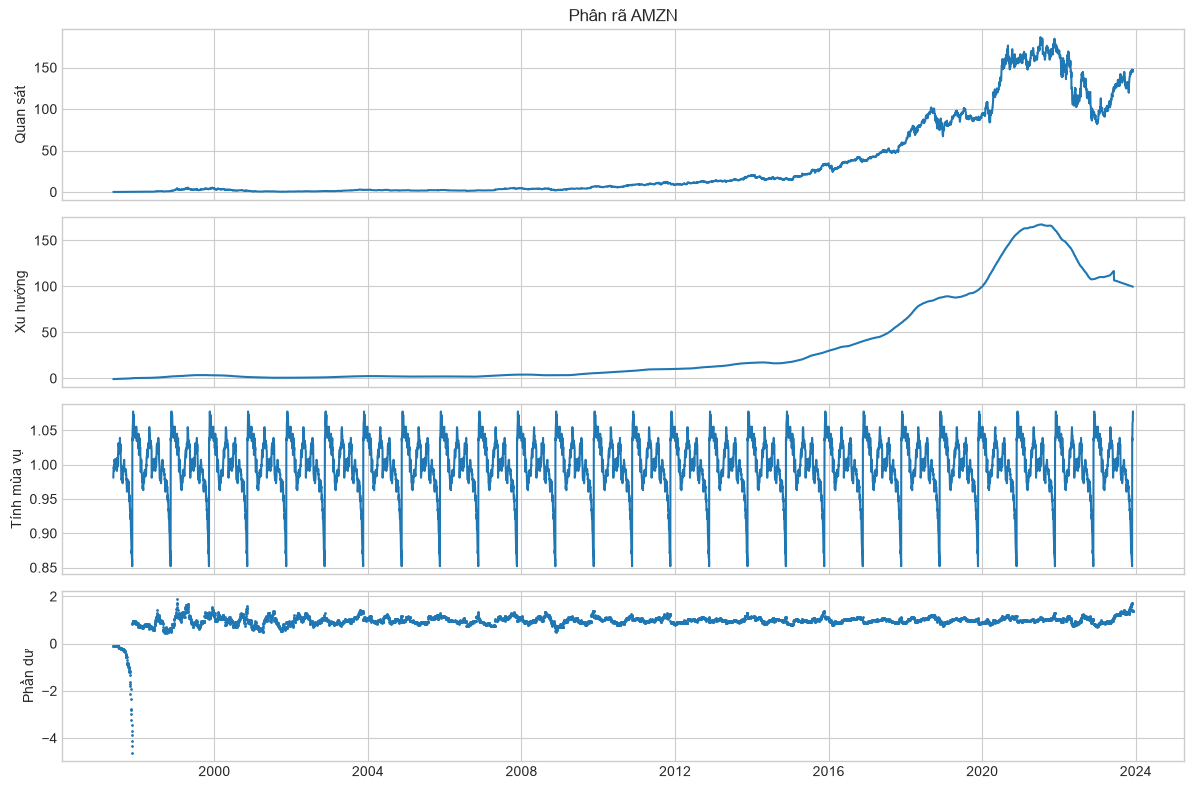

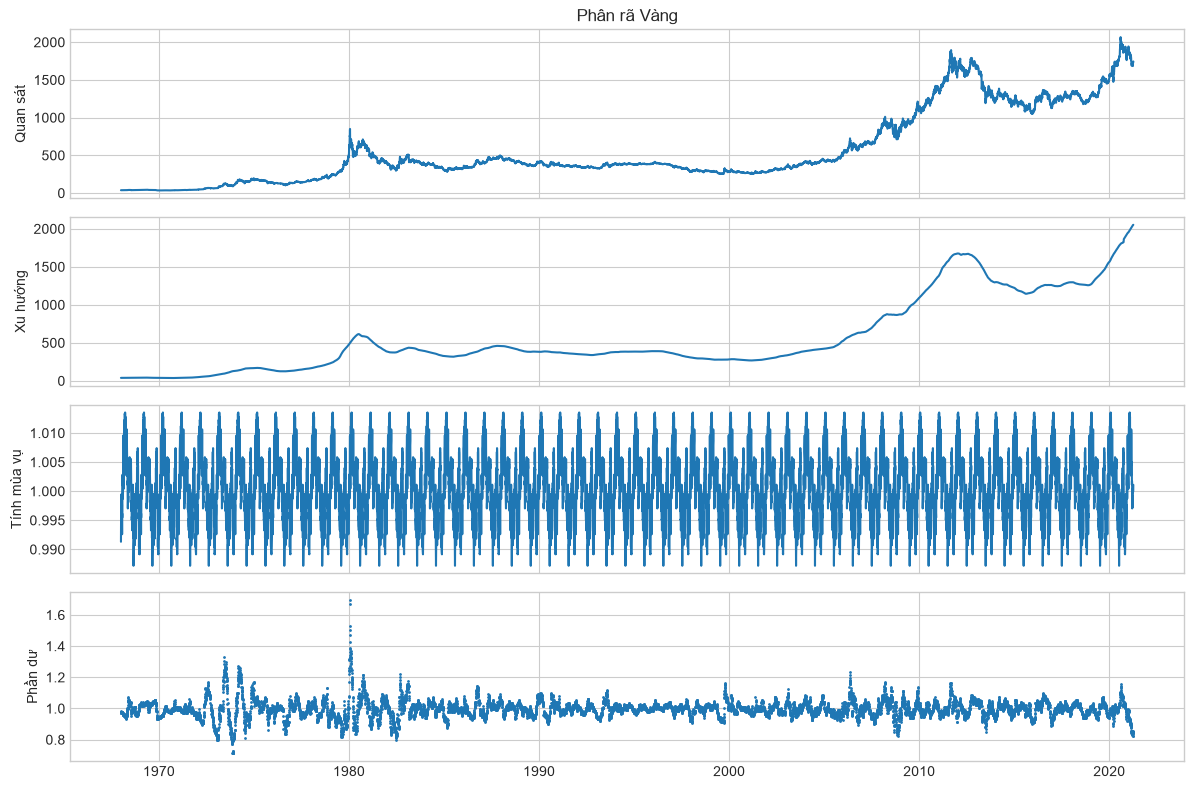

In [5]:
def plot_decomposition(series, title, period=252):
    decomp = seasonal_decompose(series, model='multiplicative', period=period, extrapolate_trend='freq')
    fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
    
    axes[0].plot(decomp.observed)
    axes[0].set_ylabel('Quan sát')
    axes[0].set_title(title)
    
    axes[1].plot(decomp.trend)
    axes[1].set_ylabel('Xu hướng')
    
    axes[2].plot(decomp.seasonal)
    axes[2].set_ylabel('Tính mùa vụ')
    
    axes[3].scatter(series.index, decomp.resid, s=1)
    axes[3].set_ylabel('Phần dư')
    
    plt.tight_layout()
    plt.show()

plot_decomposition(df_amzn['Close'].dropna(), 'Phân rã AMZN')
plot_decomposition(df_gold[target_gold].dropna(), 'Phân rã Vàng')


## Kiểm định Tính Dừng (ADF & KPSS)

Một chuỗi thời gian dừng có các tính chất thống kê (trung bình, phương sai) không thay đổi theo thời gian.
- **Kiểm định ADF**: Giả thuyết không là chuỗi có nghiệm đơn vị (không dừng).
- **Kiểm định KPSS**: Giả thuyết không là chuỗi dừng quanh một xu hướng xác định.


In [6]:
def run_stationarity_tests(series, name):
    print(f"--- Kiểm định Tính dừng cho {name} ---")
    
    # ADF
    adf_result = adfuller(series.dropna())
    print(f"Thống kê ADF: {adf_result[0]:.4f}")
    print(f"p-value ADF: {adf_result[1]:.4f}")
    
    # KPSS
    kpss_result = kpss(series.dropna(), regression='c', nlags="auto")
    print(f"Thống kê KPSS: {kpss_result[0]:.4f}")
    print(f"p-value KPSS: {kpss_result[1]:.4f}")
    print()

run_stationarity_tests(df_amzn['Close'], "AMZN")
run_stationarity_tests(df_gold[target_gold], "Vàng")


--- Kiểm định Tính dừng cho AMZN ---


Thống kê ADF: 0.3822
p-value ADF: 0.9808
Thống kê KPSS: 9.0029
p-value KPSS: 0.0100

--- Kiểm định Tính dừng cho Vàng ---


Thống kê ADF: 0.4611
p-value ADF: 0.9836
Thống kê KPSS: 13.1264
p-value KPSS: 0.0100



## Tự Tương quan & Cấu trúc Trễ (ACF/PACF)

Biểu đồ ACF và PACF cung cấp thông tin để chúng ta chọn độ dài chuỗi (cửa sổ nhìn lại - look-back window) cho các mô hình RNN.
- ACF biểu thị sự tương quan với các độ trễ lịch sử.
- PACF biểu thị tác động trực tiếp của một độ trễ, loại bỏ các tác động gián tiếp.

Sự suy giảm chậm trong ACF thường chỉ ra một quá trình không dừng. Các đỉnh nhọn đáng kể trong PACF chỉ ra các độ trễ tức thời tối ưu để đưa vào làm đặc trưng (hoặc làm độ dài chuỗi).


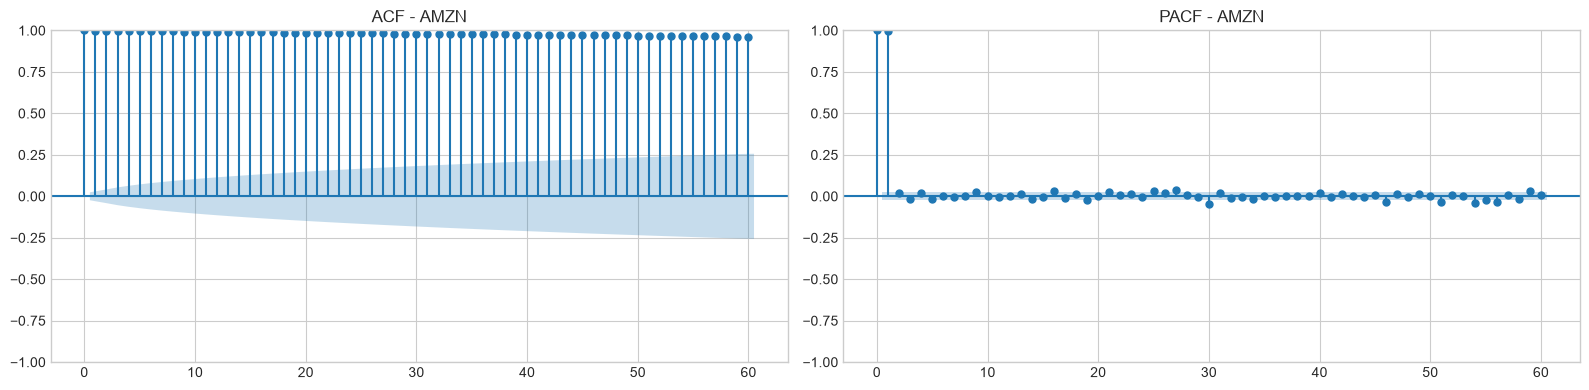

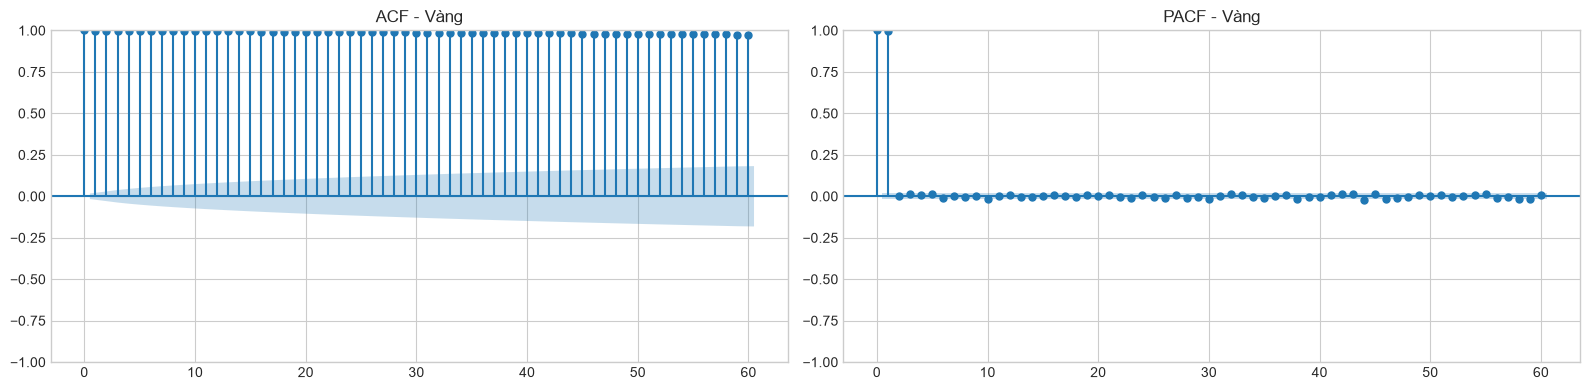

In [7]:
def plot_acf_pacf(series, title):
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))
    
    plot_acf(series.dropna(), lags=60, ax=axes[0], title=f'ACF - {title}')
    plot_pacf(series.dropna(), lags=60, ax=axes[1], title=f'PACF - {title}')
    
    plt.tight_layout()
    plt.show()

plot_acf_pacf(df_amzn['Close'], "AMZN")
plot_acf_pacf(df_gold[target_gold], "Vàng")


## Phân tích & Lựa chọn Độ dài Chuỗi Tối ưu

Dựa trên bản chất phi dừng ở mức độ cao (p-value ADF > 0.05, p-value KPSS < 0.05) và sự suy giảm cực kỳ chậm của biểu đồ ACF, cả hai bộ dữ liệu đều cho thấy sự phụ thuộc và xu hướng dài hạn rất mạnh.

PACF hầu hết bị ngắt (cut off) đột ngột sau 1-2 độ trễ, điều này rất đặc trưng cho dữ liệu tài chính dạng bước ngẫu nhiên (random-walk-like). Tuy nhiên, đối với việc lập mô hình RNN/LSTM/GRU, bối cảnh chuỗi dài hơn sẽ giúp các trạng thái ẩn học được các đặc điểm xu hướng cục bộ và các chế độ biến động.

**Kết luận:** Chúng tôi sẽ chọn độ dài chuỗi (ví dụ: $T=30$ hoặc $T=60$ ngày giao dịch) để cung cấp cho mô hình của mình bối cảnh lịch sử của khoảng 1-2 tháng nhằm dự đoán bước thời gian tiếp theo.
